In [1]:
# ==== Compare WITH anomalies vs AFTER DROPPING anomalies (same output structure) ====
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    precision_score, recall_score, f1_score, average_precision_score
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    IsolationForest, RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# ---------- 0) Load + minimal features ----------
PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
df = pd.read_csv(PATH, low_memory=False)

df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")      # target
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df = df.dropna(subset=["date","count","duration"]).copy()

# simple time features
df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# --- meta to print later (NO effect on modeling/splits) ---
meta_all = df[["poi_id", "poi", "date"]].copy()
meta_all["date_str"] = meta_all["date"].dt.strftime("%Y%m%d")

feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in {"count","anomaly_label","anomaly_score"}]
X_all = df[feat_cols].fillna(0).to_numpy(np.float32)
y_all = df["count"].to_numpy(np.float32)

# ---------- 1) Models to evaluate ----------
candidates = [
    ("rf",    RandomForestRegressor(n_estimators=600, max_depth=None,
                                    min_samples_split=2, min_samples_leaf=1,
                                    max_features="sqrt", n_jobs=-1, random_state=42)),
    ("xgb",   XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, tree_method="hist")),
    ("etr",   ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                  min_samples_leaf=1, max_features="sqrt",
                                  n_jobs=-1, random_state=42)),
    ("gbr",   GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("dt",    DecisionTreeRegressor(max_depth=12, random_state=42)),
    ("lr",    LinearRegression()),
    ("ridge", Ridge(alpha=1.0, random_state=42)),
    ("bayes", BayesianRidge()),
    ("huber", HuberRegressor(epsilon=1.35)),
]

# ---------- 2) Helper: rank models on one split ----------
def rank_models_on_split(X_tr, X_te, y_tr, y_te, candidates, label):
    TH = float(np.median(y_tr))  # threshold for P/R/F1/PR-AUC
    rows, fitted = [], {}
    for name, mdl in candidates:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        fitted[name] = m
        pred = m.predict(X_te)

        r2  = r2_score(y_te, pred)
        mae = mean_absolute_error(y_te, pred)

        y_true = (y_te > TH).astype(int)
        y_hat  = (pred  > TH).astype(int)

        P  = precision_score(y_true, y_hat, zero_division=0)
        R  = recall_score(y_true, y_hat, zero_division=0)
        F1 = f1_score(y_true, y_hat, zero_division=0)
        PR = average_precision_score(y_true, pred)

        rows.append({"Scenario": label, "Model": name.upper(),
                     "P": P, "R": R, "F1": F1, "PR_AUC": PR, "R2": r2, "MAE": mae})

    rank_df = (pd.DataFrame(rows)
                 .sort_values(["F1","PR_AUC","R2","MAE","P","R"],
                              ascending=[False,False,False,True,False,False])
                 .reset_index(drop=True))
    return rank_df

# ---------- 3) Scenario A: WITH anomalies (no drop) ----------
X_tr_A, X_te_A, y_tr_A, y_te_A = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
rank_with = rank_models_on_split(X_tr_A, X_te_A, y_tr_A, y_te_A, candidates, label="WITH_ANOMALIES")

# ---------- 4) Scenario B: AFTER DROPPING anomalies (IsolationForest prefilter) ----------
PREFILTER_CONTAM = 0.10
Z = StandardScaler().fit_transform(X_all)  # unsupervised, no target leakage
gate = IsolationForest(contamination=PREFILTER_CONTAM, random_state=42).fit(Z)
keep_mask = (gate.predict(Z) == 1)  # 1=normal, -1=anomaly
X_clean, y_clean = X_all[keep_mask], y_all[keep_mask]

# align meta with cleaned rows (printing only; no modeling change)
meta_clean = meta_all[keep_mask].reset_index(drop=True)

print(f"Dropped {len(y_all) - len(y_clean)} anomalies "
      f"({100*(1 - len(y_clean)/len(y_all)):.1f}%) using IsolationForest prefilter.")

# Split Scenario B WITH meta (does not alter X/y permutation)
X_tr_B, X_te_B, y_tr_B, y_te_B, m_tr_B, m_te_B = train_test_split(
    X_clean, y_clean, meta_clean, test_size=0.2, random_state=42
)
rank_wo = rank_models_on_split(X_tr_B, X_te_B, y_tr_B, y_te_B, candidates, label="NO_ANOMALIES")

# ---------- 5) Print BOTH tables (identical structure) ----------
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== RANKED (WITH anomalies) ===")
print(rank_with[["Model","P","R","F1","PR_AUC","R2","MAE"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== RANKED (AFTER DROPPING anomalies) ===")
print(rank_wo[["Model","P","R","F1","PR_AUC","R2","MAE"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ---------- 6) Optional: side-by-side comparison by Model ----------
cmp = (rank_with.merge(rank_wo, on="Model", suffixes=("_WITH","_NOANOM"))
               .loc[:, ["Model",
                        "F1_WITH","F1_NOANOM",
                        "PR_AUC_WITH","PR_AUC_NOANOM",
                        "R2_WITH","R2_NOANOM",
                        "MAE_WITH","MAE_NOANOM",
                        "P_WITH","P_NOANOM","R_WITH","R_NOANOM"]])

print("\n=== SIDE-BY-SIDE (same models) ===")
print(cmp.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ---------- 7) Ensembles (Top-3) + Top-3 hybrid avg ----------
# Take Top-3 models from NO_ANOMALIES ranking
top3_noanom = rank_wo["Model"].head(3).tolist()   # e.g., ["XGB","RF","ETR"]
top3 = list(dict.fromkeys(top3_noanom))
assert len(top3) == 3, f"Expected 3 unique models in top3, got {top3}"



c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.78166e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Dropped 12363 anomalies (10.0%) using IsolationForest prefilter.


c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.30015e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



=== RANKED (WITH anomalies) ===
Model     P     R    F1  PR_AUC    R2   MAE
  ETR 0.988 0.998 0.993   1.000 0.982 4.738
   RF 0.988 0.998 0.993   1.000 0.981 5.413
  GBR 0.994 0.987 0.990   1.000 0.991 6.993
RIDGE 0.985 0.994 0.989   1.000 1.000 0.757
BAYES 0.985 0.994 0.989   1.000 1.000 0.753
  XGB 0.986 0.988 0.987   0.999 0.986 5.836
   LR 0.978 0.995 0.987   0.999 0.999 3.304
HUBER 0.985 0.988 0.986   0.999 0.998 5.200
   DT 0.974 0.978 0.976   0.995 0.981 9.833

=== RANKED (AFTER DROPPING anomalies) ===
Model     P     R    F1  PR_AUC    R2   MAE
   RF 0.979 0.998 0.988   1.000 0.998 1.410
  ETR 0.979 0.998 0.988   1.000 0.998 1.209
BAYES 0.972 0.999 0.986   1.000 1.000 0.374
RIDGE 0.972 0.999 0.986   1.000 1.000 0.374
  GBR 0.980 0.989 0.984   0.999 0.999 1.667
  XGB 0.975 0.993 0.984   0.999 0.999 1.345
   DT 0.972 0.981 0.977   0.997 0.997 2.676
HUBER 0.971 0.981 0.976   0.998 0.997 3.000
   LR 0.944 0.982 0.963   0.996 0.996 3.974

=== SIDE-BY-SIDE (same models) ===
Model  F

In [3]:
# We'll ensemble on the NO_ANOMALIES split
X_tr, X_te, y_tr, y_te = X_tr_B, X_te_B, y_tr_B, y_te_B

# Map model name -> estimator from `candidates` (uppercase keys)
cand_map = {name.upper(): est for name, est in candidates}
for nm in top3:
    assert nm in cand_map, f"{nm} not in candidates: {list(cand_map)}"

# Base learners for ensembles (must be uppercase names)
bases = [(nm, clone(cand_map[nm])) for nm in top3]

# Small cache of fitted base candidates (keys are original names: 'rf','xgb',...)
fitted = {name: clone(est).fit(X_tr, y_tr) for name, est in candidates}

# Voting (equal weights across Top-3)
vote = VotingRegressor(bases).fit(X_tr, y_tr)
pred_vote = vote.predict(X_te)

# Stacking with several meta-learners
stack_lin = StackingRegressor(
    estimators=bases,
    final_estimator=LinearRegression(),
    cv=3, passthrough=True
).fit(X_tr, y_tr)
pred_stack_lin = stack_lin.predict(X_te)

stack_ridge = StackingRegressor(
    estimators=bases,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=3, passthrough=True
).fit(X_tr, y_tr)
pred_stack_ridge = stack_ridge.predict(X_te)

stack_gbr = StackingRegressor(
    estimators=bases,
    final_estimator=GradientBoostingRegressor(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=3),
    cv=3, passthrough=True
).fit(X_tr, y_tr)
pred_stack_gbr = stack_gbr.predict(X_te)

# ---- Hybrid (Top-3 equal-weight average) ----
def _predict_from_name(nm_upper: str):
    key_l = nm_upper.lower()
    if key_l in fitted:
        return fitted[key_l].predict(X_te)
    return clone(cand_map[nm_upper]).fit(X_tr, y_tr).predict(X_te)

_top3_preds = [_predict_from_name(nm) for nm in top3]     # e.g., preds from ["XGB","RF","ETR"]
pred_avg = np.mean(np.column_stack(_top3_preds), axis=1)

# ---------- 8) Report ----------
def show(name, yt, yp):
    print(f"{name:<24} R2={r2_score(yt, yp):.4f}  MAE={mean_absolute_error(yt, yp):.4f}")

print("\n=== Ensembles with Top-3 bases (NO_ANOMALIES split) ===")
show("Voting (Top-3, equal)", y_te, pred_vote)
show("Stack (Linear meta)",   y_te, pred_stack_lin)
show("Stack (Ridge meta)",    y_te, pred_stack_ridge)
show("Stack (GBR meta)",      y_te, pred_stack_gbr)
show("Hybrid (Top-3 avg)",    y_te, pred_avg)



MemoryError: could not allocate 4194304 bytes

In [ ]:
# ---------- 9) Sample rows with POI/DATE — Actual vs Predicted (NO_ANOMALIES test split) ----------
N_SHOW = min(10, len(m_te_B))  # exactly up to 10 test rows

print("\n-- Voting (Top-3, equal) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_vote[i]))}")

print("\n-- Stack (Linear meta) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_stack_lin[i]))}")

print("\n-- Stack (Ridge meta) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_stack_ridge[i]))}")

print("\n-- Stack (GBR meta) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_stack_gbr[i]))}")

print("\n-- Hybrid (Top-3 avg) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_avg[i]))}")



-- Voting (Top-3, equal) --
POI_ID | POI_NAME | DATE | Actual | Predicted
6525.0 | Gallagher Canyon | 20220105 | 14 | 14
5710.0 | Carter Lake | 20220924 | 36 | 36
5745.0 | Holmes | 20220903 | 35 | 35
6915.0 | Harlan County Reservoir (COE) | 20221201 | 14 | 14
6725.0 | Holdrege City Lake (North Park) | 20220902 | 52 | 52
6080.0 | Mormon Island West (MM 312N) | 20221118 | 13 | 13
4540.0 | Lake McConaughy | 20220428 | 15 | 15
5745.0 | Holmes | 20220701 | 30 | 30
3710.0 | Lewis & Clark Lake | 20240604 | 532 | 532
6716.0 | GI Pier Park Lake | 20220119 | 14 | 14

-- Stack (Linear meta) --
POI_ID | POI_NAME | DATE | Actual | Predicted
6525.0 | Gallagher Canyon | 20220105 | 14 | 14
5710.0 | Carter Lake | 20220924 | 36 | 37
5745.0 | Holmes | 20220903 | 35 | 35
6915.0 | Harlan County Reservoir (COE) | 20221201 | 14 | 14
6725.0 | Holdrege City Lake (North Park) | 20220902 | 52 | 52
6080.0 | Mormon Island West (MM 312N) | 20221118 | 13 | 13
4540.0 | Lake McConaughy | 20220428 | 15 | 16
5745.0 | H

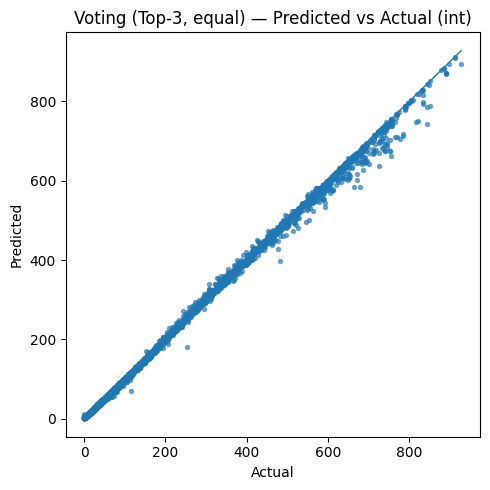

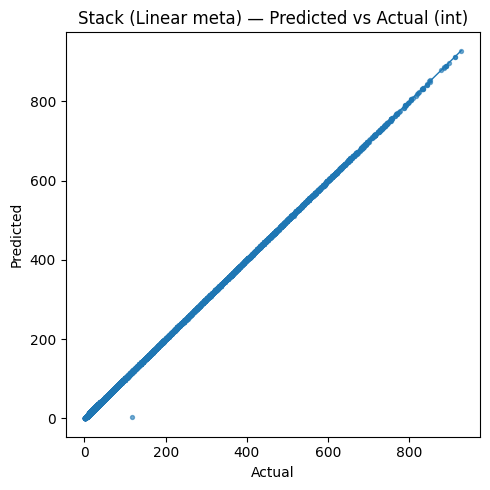

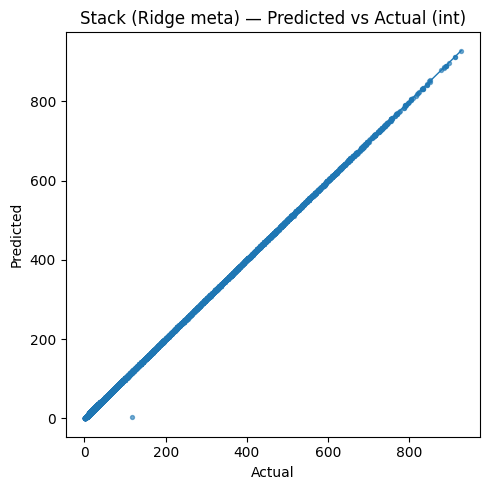

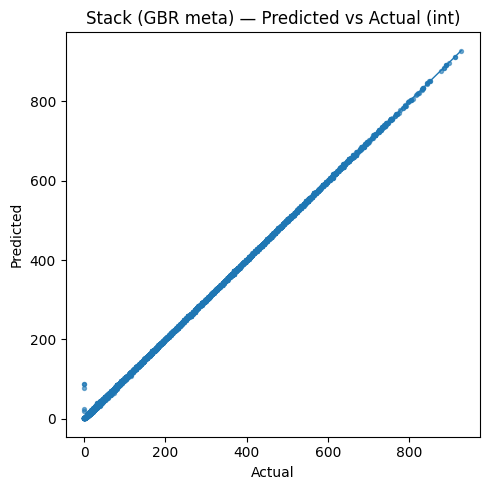

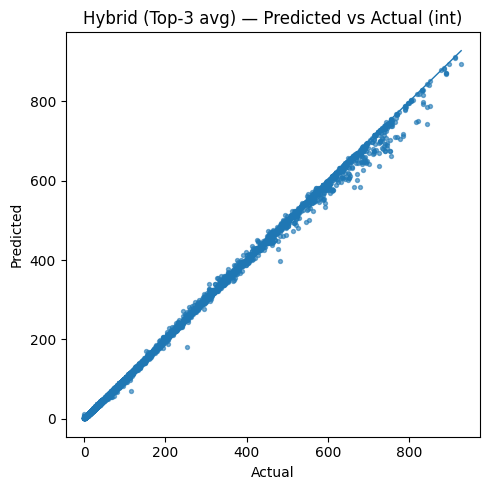

In [ ]:
# ---------- Scatter plots (Predicted vs Actual, integers only) ----------
import numpy as np
import matplotlib.pyplot as plt

# Actuals as integers
y_true_int = np.rint(y_te).astype(int)

# Optional downsample to keep plots responsive
idx_all = np.arange(len(y_true_int))
SAMPLE = min(50000, len(idx_all))
if SAMPLE < len(idx_all):
    rng = np.random.RandomState(42)
    idx = np.sort(rng.choice(len(idx_all), size=SAMPLE, replace=False))
else:
    idx = idx_all

# Helper inline variables reused per model (no functions)
# Each block below: round preds to int, subset by idx, plot Predicted vs Actual with y=x reference

if 'pred_vote' in locals():
    yp = np.rint(pred_vote).astype(int)[idx]
    ya = y_true_int[idx]
    lo = int(min(ya.min(), yp.min())); hi = int(max(ya.max(), yp.max()))
    plt.figure(figsize=(5,5))
    plt.scatter(ya, yp, s=8, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], linewidth=1)
    plt.title("Voting (Top-3, equal) — Predicted vs Actual (int)")
    plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.tight_layout(); plt.show()

if 'pred_stack_lin' in locals():
    yp = np.rint(pred_stack_lin).astype(int)[idx]
    ya = y_true_int[idx]
    lo = int(min(ya.min(), yp.min())); hi = int(max(ya.max(), yp.max()))
    plt.figure(figsize=(5,5))
    plt.scatter(ya, yp, s=8, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], linewidth=1)
    plt.title("Stack (Linear meta) — Predicted vs Actual (int)")
    plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.tight_layout(); plt.show()

if 'pred_stack_ridge' in locals():
    yp = np.rint(pred_stack_ridge).astype(int)[idx]
    ya = y_true_int[idx]
    lo = int(min(ya.min(), yp.min())); hi = int(max(ya.max(), yp.max()))
    plt.figure(figsize=(5,5))
    plt.scatter(ya, yp, s=8, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], linewidth=1)
    plt.title("Stack (Ridge meta) — Predicted vs Actual (int)")
    plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.tight_layout(); plt.show()

if 'pred_stack_gbr' in locals():
    yp = np.rint(pred_stack_gbr).astype(int)[idx]
    ya = y_true_int[idx]
    lo = int(min(ya.min(), yp.min())); hi = int(max(ya.max(), yp.max()))
    plt.figure(figsize=(5,5))
    plt.scatter(ya, yp, s=8, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], linewidth=1)
    plt.title("Stack (GBR meta) — Predicted vs Actual (int)")
    plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.tight_layout(); plt.show()

if 'pred_avg' in locals():
    yp = np.rint(pred_avg).astype(int)[idx]
    ya = y_true_int[idx]
    lo = int(min(ya.min(), yp.min())); hi = int(max(ya.max(), yp.max()))
    plt.figure(figsize=(5,5))
    plt.scatter(ya, yp, s=8, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], linewidth=1)
    plt.title("Hybrid (Top-3 avg) — Predicted vs Actual (int)")
    plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.tight_layout(); plt.show()


In [ ]:
# ---- Scatter plots (each stacker): Actual vs Predicted ----
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

def scatter_actual_vs_pred(y_true, y_pred, title, save_path=None, show_identity=True):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # figure
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=12, alpha=0.6)

    # identity line
    if show_identity:
        vmin = float(min(np.min(y_true), np.min(y_pred)))
        vmax = float(max(np.max(y_true), np.max(y_pred)))
        plt.plot([vmin, vmax], [vmin, vmax])  # 45° line
        plt.xlim(vmin, vmax)
        plt.ylim(vmin, vmax)

    # metrics in subtitle
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    plt.title(f"{title}\nR²={r2:.3f}   MAE={mae:.3f}")
    plt.xlabel("Actual count")
    plt.ylabel("Predicted count")
    plt.tight_layout()

    # save + show
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

# where to save
plot_dir = Path("outputs/Compare_Anomalies/plots")

# --- make one plot per stacker ---
scatter_actual_vs_pred(y_te, pred_stack_lin,
                       "Stack (Linear meta) — Actual vs Predicted",
                       plot_dir / "scatter_stack_linear.png")

scatter_actual_vs_pred(y_te, pred_stack_ridge,
                       "Stack (Ridge meta) — Actual vs Predicted",
                       plot_dir / "scatter_stack_ridge.png")

scatter_actual_vs_pred(y_te, pred_stack_gbr,
                       "Stack (GBR meta) — Actual vs Predicted",
                       plot_dir / "scatter_stack_gbr.png")


NameError: name 'y_te' is not defined